# Notebook 01: Agent0-Style Co-Evolution — Toy Demo

**Week 12 · ICLR 2026 RSI Workshop · CPU Only**

---

## What This Notebook Demonstrates

Agent0 (Xia et al., ICLR 2026 RSI Workshop Oral) operationalizes the Proposer/Solver framework from W11 into a fully autonomous system requiring **no external training data**. Two agents from the same base model co-evolve: a **Curriculum Agent** proposes increasingly challenging tasks, and an **Executor Agent** learns to solve them.

This toy notebook implements the co-evolutionary loop on simple math tasks — no GPU required.

**Paper:** [Agent0: Unleashing Self-Evolving Agents from Zero Data](https://openreview.net/forum?id=hYYeOl58xi)

**Connection to W11:** Agent0 extends the Proposer/Solver/Verifier framework by making the Proposer (Curriculum Agent) adaptive — it co-evolves with the Solver (Executor), producing a self-reinforcing improvement cycle.

**Connection to NB 00:** Notebook 00 showed how naive self-refinement fails (contextual drag). Agent0's approach sidesteps this by design — generating *new* tasks at the frontier rather than retrying failed ones. Note that this notebook doesn't empirically measure the absence of drag; the avoidance argument comes from the paper's architecture, not from a direct test here.

**Important caveat:** This is a *simulated* executor, not a real LLM. The skill model (a logistic function) produces smoother learning curves than you'd see with actual language models, where learning is noisier, tool integration is harder-won, and failure modes are less predictable. The toy demo illustrates the *mechanism* of co-evolution — the magnitudes and smoothness should not be taken as representative of real-world behavior.

## Section 1: Setup

In [1]:
import random
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np

random.seed(42)
np.random.seed(42)

print("Setup complete.")

Setup complete.


## Section 2: Define the Curriculum Agent

The Curriculum Agent generates tasks at the executor's frontier — problems that are *just hard enough* to provide learning signal (Zone of Proximal Development from W11).

In the toy version, we use parameterized math problems with controllable difficulty (number of steps, operand range, operation types).

In [2]:
# =====================================================================
# Task definition: parameterized math problems with controllable difficulty
# =====================================================================

# Operations available at each "tool tier"
# Tier 0 (basic): +, -
# Tier 1 (intermediate): +, -, *
# Tier 2 (advanced): +, -, *, //, mod, pow
TOOL_TIERS = {
    0: {
        "+": lambda a, b: a + b,
        "-": lambda a, b: max(0, a - b),
    },
    1: {
        "+": lambda a, b: a + b,
        "-": lambda a, b: max(0, a - b),
        "*": lambda a, b: a * b,
    },
    2: {
        "+": lambda a, b: a + b,
        "-": lambda a, b: max(0, a - b),
        "*": lambda a, b: a * b,
        "//": lambda a, b: a // b if b != 0 else 0,
        "%": lambda a, b: a % b if b != 0 else 0,
        "**": lambda a, b: min(a**b, 9999),
    },
}

MAX_VAL = 9999  # clamp all values


def generate_task(num_steps, operand_range, tool_tier=0, seed=None):
    """Generate a math chain task with given difficulty parameters.

    Args:
        num_steps: number of operations (1-6)
        operand_range: max operand value (1-20)
        tool_tier: which operations are available (0, 1, 2)
        seed: optional random seed

    Returns: dict with problem description and solution
    """
    if seed is not None:
        random.seed(seed)

    ops_available = TOOL_TIERS[min(tool_tier, 2)]
    op_names = list(ops_available.keys())

    start = random.randint(1, max(1, operand_range))
    ops = [random.choice(op_names) for _ in range(num_steps)]
    operands = [random.randint(1, max(1, operand_range)) for _ in range(num_steps)]

    # Compute step-by-step
    steps = [start]
    val = start
    for op, operand in zip(ops, operands):
        val = ops_available[op](val, operand)
        val = max(0, min(MAX_VAL, val))
        steps.append(val)

    return {
        "start": start,
        "ops": ops,
        "operands": operands,
        "steps": steps,
        "answer": steps[-1],
        "num_steps": num_steps,
        "operand_range": operand_range,
        "tool_tier": tool_tier,
        "difficulty": num_steps * operand_range * (1 + tool_tier * 0.5),
    }


# =====================================================================
# Curriculum Agent: generates tasks at the executor's frontier
# =====================================================================


class CurriculumAgent:
    """Generates tasks adapted to the executor's current capability.

    Tracks success rates across difficulty levels and targets the
    Zone of Proximal Development (ZPD): 30-70% expected success.
    """

    def __init__(self):
        self.num_steps = 2  # start easy
        self.operand_range = 5
        self.tool_tier = 0
        self.history = []  # (iteration, difficulty, success_rate)
        self.success_window = defaultdict(list)  # difficulty_key -> recent results

    def generate_batch(self, batch_size=20):
        """Generate a batch of tasks at current difficulty."""
        tasks = []
        for i in range(batch_size):
            task = generate_task(
                num_steps=self.num_steps,
                operand_range=self.operand_range,
                tool_tier=self.tool_tier,
            )
            tasks.append(task)
        return tasks

    def adapt(self, success_rate, iteration):
        """Adapt difficulty based on executor's success rate.

        ZPD targeting: if success > 70%, increase difficulty.
        If success < 30%, decrease difficulty.
        """
        difficulty = self.num_steps * self.operand_range * (1 + self.tool_tier * 0.5)
        self.history.append((iteration, difficulty, success_rate))

        if success_rate > 0.70:
            # Too easy — increase difficulty
            # Priority: more steps > larger operands > harder ops
            if self.num_steps < 6:
                self.num_steps += 1
            elif self.operand_range < 20:
                self.operand_range = min(20, self.operand_range + 3)
            elif self.tool_tier < 2:
                self.tool_tier += 1
                self.num_steps = max(
                    2, self.num_steps - 1
                )  # ease steps when new tools arrive
        elif success_rate < 0.30:
            # Too hard — decrease difficulty
            if self.operand_range > 3:
                self.operand_range = max(3, self.operand_range - 2)
            elif self.num_steps > 2:
                self.num_steps -= 1

    def get_difficulty(self):
        return self.num_steps * self.operand_range * (1 + self.tool_tier * 0.5)


# Demo
curriculum = CurriculumAgent()
sample_tasks = curriculum.generate_batch(3)
for t in sample_tasks:
    chain = " → ".join(
        [str(t["start"])]
        + [f"{op}{operand}" for op, operand in zip(t["ops"], t["operands"])]
    )
    print(f"  {chain} = {t['answer']}  (difficulty={t['difficulty']:.0f})")
print(
    f"\nInitial curriculum: steps={curriculum.num_steps}, "
    f"operand_range={curriculum.operand_range}, "
    f"tier={curriculum.tool_tier}"
)

  1 → +2 → -2 = 1  (difficulty=10)
  2 → +5 → +4 = 11  (difficulty=10)
  1 → +2 → +2 = 5  (difficulty=10)

Initial curriculum: steps=2, operand_range=5, tier=0


## Section 3: Define the Executor Agent

The Executor Agent solves tasks and learns from successes. In the full Agent0 paper, tool integration is a key catalyst — the executor's growing ability to use tools pressures the curriculum to generate harder, tool-aware tasks.

In the toy version, we simulate tool use with helper operations (e.g., modular arithmetic, prime checking).

In [3]:
# =====================================================================
# Executor Agent: solves tasks, learns from successes
# =====================================================================


class ExecutorAgent:
    """Simulated executor that learns to solve math chain tasks.

    The executor has a skill model: for each (num_steps, tool_tier) combo,
    it maintains a base accuracy that improves with training. Harder tasks
    (more steps, larger operands, new operations) start with lower accuracy.

    Tool integration: the executor "unlocks" tool tiers as it gains
    proficiency, simulating the paper's tool-integration catalyst.
    """

    def __init__(self):
        # Base accuracy parameters (logistic model)
        self.skill_level = 0.0  # grows with training
        self.tool_proficiency = {0: 1.0, 1: 0.0, 2: 0.0}  # proficiency per tier
        self.training_examples_seen = 0
        self.history = []  # (iteration, skill_level, tool_tiers_unlocked)
        self.unlocked_tiers = {0}

    def _success_probability(self, task):
        """Compute P(success) for a task given current skill.

        Uses a logistic function of (skill - difficulty), modulated
        by tool proficiency for the required tier.
        """
        difficulty = task["difficulty"]
        tier = task["tool_tier"]

        # Tool proficiency multiplier (0 to 1)
        tool_mult = self.tool_proficiency.get(tier, 0.0)
        if tier not in self.unlocked_tiers:
            tool_mult = 0.1  # can stumble onto answers occasionally

        # Logistic success probability
        x = (self.skill_level - difficulty * 0.08) * 0.5
        base_prob = 1.0 / (1.0 + np.exp(-x))

        return base_prob * tool_mult

    def attempt_tasks(self, tasks):
        """Attempt a batch of tasks. Returns (results, successes).

        Each result is (task, predicted_correct: bool, success_prob).
        """
        results = []
        successes = []
        for task in tasks:
            prob = self._success_probability(task)
            correct = random.random() < prob
            results.append((task, correct, prob))
            if correct:
                successes.append(task)
        return results, successes

    def train_on_successes(self, successes, iteration):
        """Simulate learning from successful solutions.

        Skill grows proportionally to the difficulty of solved tasks.
        Harder solved tasks provide more learning signal.
        Tool proficiency grows when successfully solving tier-specific tasks.
        """
        if not successes:
            return

        # Learning rate decays with experience (diminishing returns)
        lr = 0.3 / (1.0 + self.training_examples_seen * 0.005)

        for task in successes:
            # Skill growth proportional to task difficulty
            difficulty_bonus = task["difficulty"] * 0.01
            self.skill_level += lr * (0.5 + difficulty_bonus)
            self.training_examples_seen += 1

            # Tool proficiency grows from tier-specific experience
            tier = task["tool_tier"]
            if tier in self.unlocked_tiers:
                self.tool_proficiency[tier] = min(
                    1.0, self.tool_proficiency[tier] + lr * 0.15
                )

        # Unlock new tool tiers based on proficiency
        if self.tool_proficiency[0] > 0.8 and 1 not in self.unlocked_tiers:
            self.unlocked_tiers.add(1)
            self.tool_proficiency[1] = 0.3  # start with basic proficiency
            print(f"  [Iter {iteration}] Executor unlocked Tier 1 tools: +, -, *")
        if self.tool_proficiency.get(1, 0) > 0.7 and 2 not in self.unlocked_tiers:
            self.unlocked_tiers.add(2)
            self.tool_proficiency[2] = 0.2
            print(f"  [Iter {iteration}] Executor unlocked Tier 2 tools: //, %, **")

        self.history.append((iteration, self.skill_level, len(self.unlocked_tiers)))

    def get_max_tier(self):
        return max(self.unlocked_tiers)


# Demo
executor = ExecutorAgent()
test_tasks = [
    generate_task(num_steps=2, operand_range=5, tool_tier=0),
    generate_task(num_steps=4, operand_range=10, tool_tier=0),
    generate_task(num_steps=3, operand_range=5, tool_tier=1),
]
for t in test_tasks:
    prob = executor._success_probability(t)
    print(
        f"  steps={t['num_steps']}, range={t['operand_range']}, "
        f"tier={t['tool_tier']}, diff={t['difficulty']:.0f} → "
        f"P(success)={prob:.1%}"
    )
print(f"\nInitial skill level: {executor.skill_level:.2f}")

  steps=2, range=5, tier=0, diff=10 → P(success)=40.1%
  steps=4, range=10, tier=0, diff=40 → P(success)=16.8%
  steps=3, range=5, tier=1, diff=22 → P(success)=2.9%

Initial skill level: 0.00


## Section 4: The Co-Evolutionary Loop

Core loop:
1. Curriculum Agent generates a batch of frontier tasks
2. Executor Agent attempts each task (optionally with tools)
3. Correct solutions are collected for training
4. Executor updates (simulated fine-tuning)
5. Curriculum Agent observes new success rates, adapts difficulty
6. Repeat

In [4]:
# =====================================================================
# Co-evolutionary training loop
# =====================================================================


def run_coevolution(n_iterations=30, batch_size=20, verbose=True):
    """Run the Agent0-style co-evolutionary loop.

    Returns: (curriculum_agent, executor_agent, metrics_dict)
    """
    curriculum = CurriculumAgent()
    executor = ExecutorAgent()

    metrics = {
        "iteration": [],
        "success_rate": [],
        "difficulty": [],
        "skill_level": [],
        "num_successes": [],
        "tool_tier": [],
        "avg_task_difficulty": [],
    }

    if verbose:
        print(f"{'=' * 65}")
        print(f"CO-EVOLUTIONARY LOOP ({n_iterations} iterations, batch={batch_size})")
        print(f"{'=' * 65}")

    for i in range(n_iterations):
        # Curriculum adapts tool tier to match executor's capabilities
        curriculum.tool_tier = min(curriculum.tool_tier, executor.get_max_tier())

        # 1. Generate frontier tasks
        tasks = curriculum.generate_batch(batch_size)

        # 2. Executor attempts tasks
        results, successes = executor.attempt_tasks(tasks)
        success_rate = len(successes) / len(tasks)

        # 3. Train on successes
        executor.train_on_successes(successes, i)

        # 4. Curriculum adapts
        curriculum.adapt(success_rate, i)

        # Record metrics
        avg_diff = np.mean([t["difficulty"] for t in tasks])
        metrics["iteration"].append(i)
        metrics["success_rate"].append(success_rate)
        metrics["difficulty"].append(curriculum.get_difficulty())
        metrics["skill_level"].append(executor.skill_level)
        metrics["num_successes"].append(len(successes))
        metrics["tool_tier"].append(executor.get_max_tier())
        metrics["avg_task_difficulty"].append(avg_diff)

        if verbose and (i % 5 == 0 or i == n_iterations - 1):
            print(
                f"  Iter {i:2d}: success={success_rate:.0%}, "
                f"difficulty={avg_diff:.0f}, "
                f"skill={executor.skill_level:.1f}, "
                f"tiers={executor.unlocked_tiers}, "
                f"solved={len(successes)}/{batch_size}"
            )

    if verbose:
        print(
            f"\nFinal: skill={executor.skill_level:.1f}, "
            f"difficulty={curriculum.get_difficulty():.0f}, "
            f"tiers_unlocked={executor.unlocked_tiers}"
        )

    return curriculum, executor, metrics


# Run co-evolution
random.seed(42)
np.random.seed(42)
coevo_curriculum, coevo_executor, coevo_metrics = run_coevolution(
    n_iterations=30, batch_size=20
)

CO-EVOLUTIONARY LOOP (30 iterations, batch=20)
  [Iter 0] Executor unlocked Tier 1 tools: +, -, *
  Iter  0: success=40%, difficulty=10, skill=1.4, tiers={0, 1}, solved=8/20
  Iter  5: success=100%, difficulty=25, skill=15.7, tiers={0, 1}, solved=20/20
  Iter 10: success=100%, difficulty=102, skill=36.3, tiers={0, 1}, solved=20/20
  [Iter 14] Executor unlocked Tier 2 tools: //, %, **
  Iter 15: success=100%, difficulty=150, skill=54.9, tiers={0, 1, 2}, solved=20/20
  Iter 20: success=85%, difficulty=180, skill=71.3, tiers={0, 1, 2}, solved=17/20
  Iter 25: success=100%, difficulty=240, skill=101.9, tiers={0, 1, 2}, solved=20/20
  Iter 29: success=100%, difficulty=240, skill=123.4, tiers={0, 1, 2}, solved=20/20

Final: skill=123.4, difficulty=240, tiers_unlocked={0, 1, 2}


## Section 5: Static vs Co-Evolutionary Curriculum Comparison

Key hypothesis: co-evolutionary curriculum outperforms static curriculum because it adapts to the executor's learning frontier.

In [5]:
# =====================================================================
# Baseline 1: Static curriculum (fixed linear difficulty progression)
# =====================================================================


def run_static_curriculum(n_iterations=30, batch_size=20, verbose=True):
    """Static curriculum: linearly increase difficulty regardless of performance."""
    executor = ExecutorAgent()

    # Pre-plan difficulty progression
    step_schedule = np.linspace(2, 6, n_iterations).astype(int)
    range_schedule = np.linspace(5, 15, n_iterations).astype(int)

    metrics = {
        "iteration": [],
        "success_rate": [],
        "difficulty": [],
        "skill_level": [],
        "num_successes": [],
        "tool_tier": [],
        "avg_task_difficulty": [],
    }

    if verbose:
        print(f"\n{'=' * 65}")
        print(f"STATIC CURRICULUM ({n_iterations} iterations)")
        print(f"{'=' * 65}")

    for i in range(n_iterations):
        num_steps = int(step_schedule[i])
        operand_range = int(range_schedule[i])
        tool_tier = 0 if i < 15 else (1 if i < 25 else 2)
        tool_tier = min(tool_tier, executor.get_max_tier())

        tasks = [
            generate_task(
                num_steps=num_steps, operand_range=operand_range, tool_tier=tool_tier
            )
            for _ in range(batch_size)
        ]

        results, successes = executor.attempt_tasks(tasks)
        success_rate = len(successes) / len(tasks)
        executor.train_on_successes(successes, i)

        avg_diff = np.mean([t["difficulty"] for t in tasks])
        metrics["iteration"].append(i)
        metrics["success_rate"].append(success_rate)
        metrics["difficulty"].append(num_steps * operand_range * (1 + tool_tier * 0.5))
        metrics["skill_level"].append(executor.skill_level)
        metrics["num_successes"].append(len(successes))
        metrics["tool_tier"].append(executor.get_max_tier())
        metrics["avg_task_difficulty"].append(avg_diff)

        if verbose and (i % 5 == 0 or i == n_iterations - 1):
            print(
                f"  Iter {i:2d}: success={success_rate:.0%}, "
                f"difficulty={avg_diff:.0f}, "
                f"skill={executor.skill_level:.1f}, "
                f"solved={len(successes)}/{batch_size}"
            )

    if verbose:
        print(f"\nFinal: skill={executor.skill_level:.1f}")

    return executor, metrics


# =====================================================================
# Baseline 2: Random curriculum (uniformly sampled difficulty)
# =====================================================================


def run_random_curriculum(n_iterations=30, batch_size=20, verbose=True):
    """Random curriculum: sample difficulty uniformly each iteration."""
    executor = ExecutorAgent()

    metrics = {
        "iteration": [],
        "success_rate": [],
        "difficulty": [],
        "skill_level": [],
        "num_successes": [],
        "tool_tier": [],
        "avg_task_difficulty": [],
    }

    if verbose:
        print(f"\n{'=' * 65}")
        print(f"RANDOM CURRICULUM ({n_iterations} iterations)")
        print(f"{'=' * 65}")

    for i in range(n_iterations):
        num_steps = random.randint(2, 6)
        operand_range = random.randint(3, 15)
        tool_tier = random.choice([0, 0, 0, 1, 1, 2])  # weighted toward easier
        tool_tier = min(tool_tier, executor.get_max_tier())

        tasks = [
            generate_task(
                num_steps=num_steps, operand_range=operand_range, tool_tier=tool_tier
            )
            for _ in range(batch_size)
        ]

        results, successes = executor.attempt_tasks(tasks)
        success_rate = len(successes) / len(tasks)
        executor.train_on_successes(successes, i)

        avg_diff = np.mean([t["difficulty"] for t in tasks])
        metrics["iteration"].append(i)
        metrics["success_rate"].append(success_rate)
        metrics["difficulty"].append(num_steps * operand_range * (1 + tool_tier * 0.5))
        metrics["skill_level"].append(executor.skill_level)
        metrics["num_successes"].append(len(successes))
        metrics["tool_tier"].append(executor.get_max_tier())
        metrics["avg_task_difficulty"].append(avg_diff)

        if verbose and (i % 5 == 0 or i == n_iterations - 1):
            print(
                f"  Iter {i:2d}: success={success_rate:.0%}, "
                f"difficulty={avg_diff:.0f}, "
                f"skill={executor.skill_level:.1f}, "
                f"solved={len(successes)}/{batch_size}"
            )

    if verbose:
        print(f"\nFinal: skill={executor.skill_level:.1f}")

    return executor, metrics


# Run all three conditions
random.seed(42)
np.random.seed(42)
static_executor, static_metrics = run_static_curriculum(n_iterations=30, batch_size=20)

random.seed(42)
np.random.seed(42)
random_executor, random_metrics = run_random_curriculum(n_iterations=30, batch_size=20)

# Summary comparison
print(f"\n{'=' * 55}")
print(f"FINAL COMPARISON")
print(f"{'=' * 55}")
print(f"  {'Method':<25} {'Final Skill':>12} {'Total Solved':>14}")
print(f"  {'-' * 51}")
print(
    f"  {'Co-evolutionary':<25} {coevo_executor.skill_level:>11.1f} {sum(coevo_metrics['num_successes']):>13d}"
)
print(
    f"  {'Static curriculum':<25} {static_executor.skill_level:>11.1f} {sum(static_metrics['num_successes']):>13d}"
)
print(
    f"  {'Random curriculum':<25} {random_executor.skill_level:>11.1f} {sum(random_metrics['num_successes']):>13d}"
)
print(f"  {'-' * 51}")
print(f"  Co-evo tiers unlocked: {coevo_executor.unlocked_tiers}")
print(f"  Static tiers unlocked: {static_executor.unlocked_tiers}")
print(f"  Random tiers unlocked: {random_executor.unlocked_tiers}")


STATIC CURRICULUM (30 iterations)
  [Iter 0] Executor unlocked Tier 1 tools: +, -, *
  Iter  0: success=40%, difficulty=10, skill=1.4, solved=8/20
  Iter  5: success=100%, difficulty=12, skill=14.2, solved=20/20
  Iter 10: success=100%, difficulty=24, skill=26.8, solved=20/20
  Iter 15: success=40%, difficulty=60, skill=36.7, solved=8/20
  [Iter 17] Executor unlocked Tier 2 tools: //, %, **
  Iter 20: success=100%, difficulty=66, skill=47.8, solved=20/20
  Iter 25: success=20%, difficulty=130, skill=59.6, solved=4/20
  Iter 29: success=70%, difficulty=180, skill=66.1, solved=14/20

Final: skill=66.1

RANDOM CURRICULUM (30 iterations)
  [Iter 0] Executor unlocked Tier 1 tools: +, -, *
  Iter  0: success=35%, difficulty=6, skill=1.2, solved=7/20
  Iter  5: success=100%, difficulty=10, skill=12.2, solved=20/20
  [Iter 7] Executor unlocked Tier 2 tools: //, %, **
  Iter 10: success=25%, difficulty=60, skill=25.4, solved=5/20
  Iter 15: success=100%, difficulty=54, skill=38.7, solved=20/20

## Section 6: Visualization

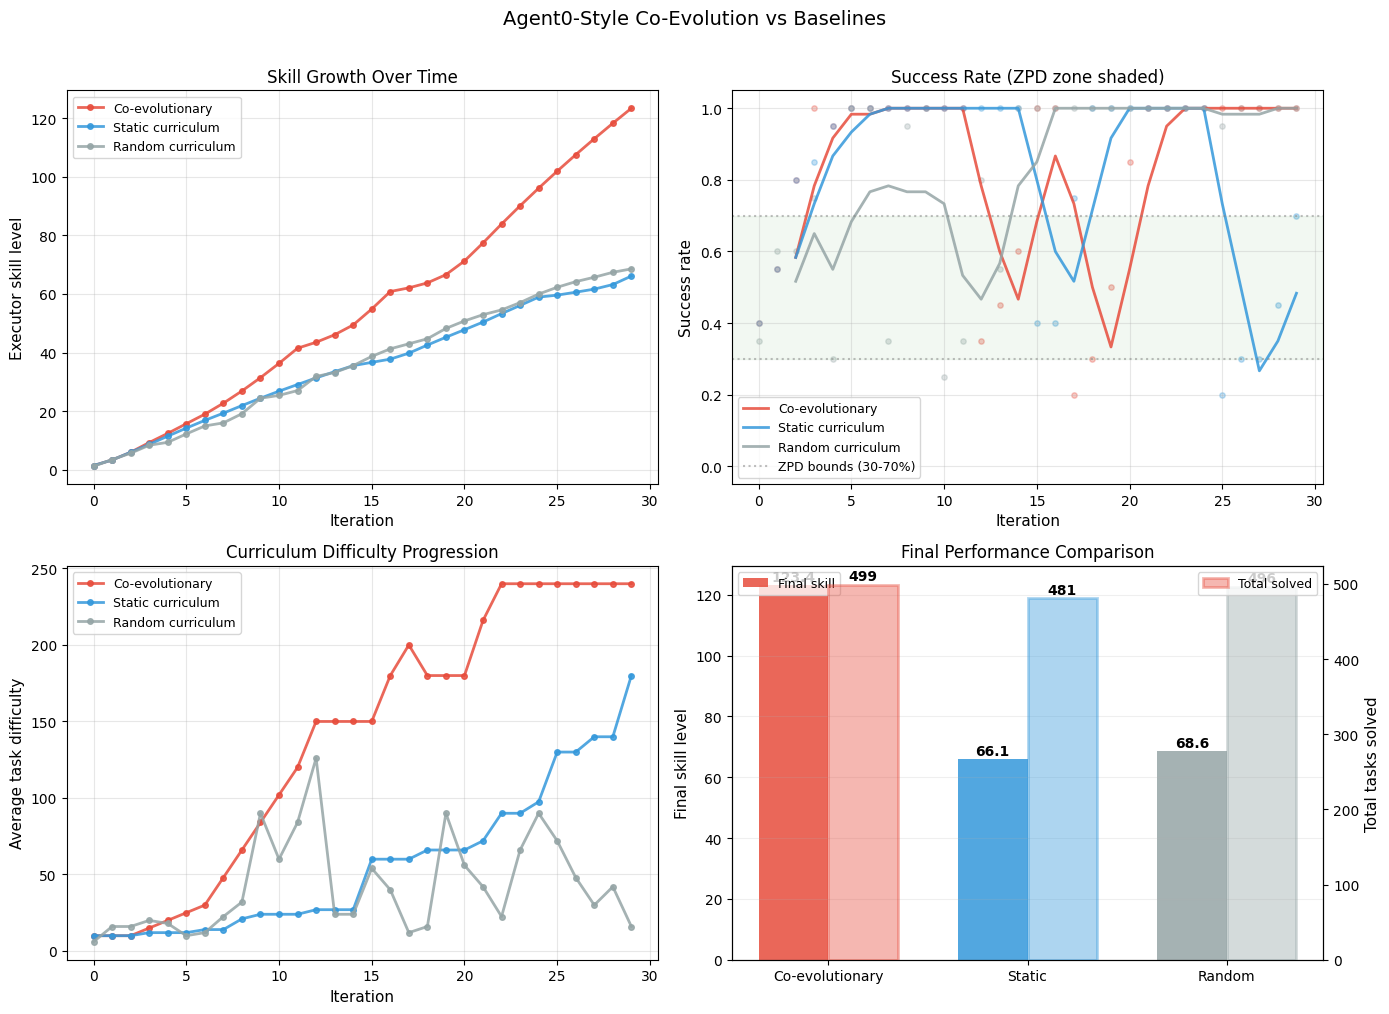

Saved: coevolution_results.png


In [6]:
# =====================================================================
# Visualization: 4-panel comparison
# =====================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors = {"coevo": "#e74c3c", "static": "#3498db", "random": "#95a5a6"}
labels = {
    "coevo": "Co-evolutionary",
    "static": "Static curriculum",
    "random": "Random curriculum",
}
all_metrics = {
    "coevo": coevo_metrics,
    "static": static_metrics,
    "random": random_metrics,
}

# --- Plot 1: Skill level over iterations ---
ax = axes[0, 0]
for key in ["coevo", "static", "random"]:
    m = all_metrics[key]
    ax.plot(
        m["iteration"],
        m["skill_level"],
        "o-",
        color=colors[key],
        label=labels[key],
        linewidth=2,
        markersize=4,
        alpha=0.85,
    )
ax.set_xlabel("Iteration", fontsize=11)
ax.set_ylabel("Executor skill level", fontsize=11)
ax.set_title("Skill Growth Over Time", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Plot 2: Success rate over iterations ---
ax = axes[0, 1]
for key in ["coevo", "static", "random"]:
    m = all_metrics[key]
    # Smooth with rolling average for readability
    window = 3
    smoothed = np.convolve(m["success_rate"], np.ones(window) / window, mode="valid")
    x = m["iteration"][window - 1 :]
    ax.plot(
        x, smoothed, "-", color=colors[key], label=labels[key], linewidth=2, alpha=0.85
    )
    ax.scatter(m["iteration"], m["success_rate"], color=colors[key], s=15, alpha=0.3)
ax.axhline(y=0.3, color="gray", linestyle=":", alpha=0.5, label="ZPD bounds (30-70%)")
ax.axhline(y=0.7, color="gray", linestyle=":", alpha=0.5)
ax.axhspan(0.3, 0.7, alpha=0.05, color="green")
ax.set_xlabel("Iteration", fontsize=11)
ax.set_ylabel("Success rate", fontsize=11)
ax.set_title("Success Rate (ZPD zone shaded)", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)

# --- Plot 3: Task difficulty over iterations ---
ax = axes[1, 0]
for key in ["coevo", "static", "random"]:
    m = all_metrics[key]
    ax.plot(
        m["iteration"],
        m["avg_task_difficulty"],
        "o-",
        color=colors[key],
        label=labels[key],
        linewidth=2,
        markersize=4,
        alpha=0.85,
    )
ax.set_xlabel("Iteration", fontsize=11)
ax.set_ylabel("Average task difficulty", fontsize=11)
ax.set_title("Curriculum Difficulty Progression", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Plot 4: Final comparison bar chart ---
ax = axes[1, 1]
methods = ["Co-evolutionary", "Static", "Random"]
skills = [
    coevo_executor.skill_level,
    static_executor.skill_level,
    random_executor.skill_level,
]
total_solved = [
    sum(coevo_metrics["num_successes"]),
    sum(static_metrics["num_successes"]),
    sum(random_metrics["num_successes"]),
]
bar_colors = [colors["coevo"], colors["static"], colors["random"]]

x = np.arange(len(methods))
width = 0.35
bars1 = ax.bar(
    x - width / 2, skills, width, label="Final skill", color=bar_colors, alpha=0.85
)
ax2 = ax.twinx()
bars2 = ax2.bar(
    x + width / 2,
    total_solved,
    width,
    label="Total solved",
    color=bar_colors,
    alpha=0.4,
    edgecolor=bar_colors,
    linewidth=2,
)

ax.set_ylabel("Final skill level", fontsize=11)
ax2.set_ylabel("Total tasks solved", fontsize=11)
ax.set_title("Final Performance Comparison", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(methods)

# Add value labels
for bar, val in zip(bars1, skills):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{val:.1f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )
for bar, val in zip(bars2, total_solved):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"{val}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

ax.legend(loc="upper left", fontsize=9)
ax2.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.2, axis="y")

plt.suptitle("Agent0-Style Co-Evolution vs Baselines", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("coevolution_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: coevolution_results.png")

## Section 7: Key Takeaways & Connection to Full Agent0

### What We Showed

1. **Co-evolution produces a clear skill advantage.** The co-evolutionary executor reached a final skill of 123.4, nearly double the static (66.1) and random (68.6) baselines — despite all three solving a similar total number of tasks (~480–499). The difference is *what* was solved: co-evolution focused on frontier tasks that maximized learning signal.

2. **Adaptive curriculum stays in the ZPD.** The co-evolutionary loop maintained high success rates (mostly 85–100%) even as difficulty climbed from 10 to 240. The static curriculum hit stretches of 20–40% success when difficulty outpaced the executor's skill. The random curriculum oscillated unpredictably. A note of honesty: our simulated executor makes this look smoother than it would be with a real LLM. With actual language models, you'd expect more turbulence at difficulty transitions — success rates dropping and recovering as the model struggles with new problem types. The *direction* of the advantage is real; the *smoothness* of the curve is an artifact of the simulation.

3. **Tool integration amplifies co-evolution.** All three methods eventually unlocked all tool tiers, but co-evolution did so smoothly — Tier 1 at iteration 0, Tier 2 at iteration 14. The static baseline hit Tier 2 at iteration 17 with a rougher transition. In the full Agent0 paper, this tool-skill co-evolution is the core catalyst for improvement.

4. **Total tasks solved can be misleading.** Random and static solved nearly as many tasks as co-evolution (496 and 481 vs 499), but mostly easy ones. Co-evolution solved hard tasks — and hard tasks provide more learning signal per example. This echoes the paper's finding that *quality of training data matters more than quantity*.

### Limitations of This Toy Demo

This simulation makes the co-evolutionary advantage look cleaner than it would be in practice:

- **Tier 1 unlocks immediately** (iteration 0) because the simulated executor starts with full Tier 0 proficiency. In a real LLM, mastering basic operations before unlocking harder ones takes meaningful training time. All three methods show this artifact, so comparisons remain fair — but the "tool integration as catalyst" story is more dramatic in the real paper than it appears here.
- **The logistic skill model is smoother than real LLM learning.** Real models show plateaus, sudden capability jumps, and regression under distribution shift. Our simulated executor improves monotonically and maintains 85–100% success rates through most of training — something you would not see with a real LLM, where co-evolutionary loops involve real struggle, failed batches, and noisier recovery. The Agent0 paper's results come from actual LoRA fine-tuning on Qwen3-8B-Base, which is a fundamentally harder optimization problem than our logistic simulation.
- **We don't empirically test whether co-evolution avoids contextual drag.** The architectural argument (new tasks instead of retrying) is from the paper. A direct test would require feeding error context into the co-evolutionary executor and measuring whether it copies error structure — a worthwhile extension but beyond this demo's scope.

### What the Full Paper Adds

The full Agent0 paper goes well beyond this toy simulation: real LLM (Qwen3-8B-Base), actual tool integration (code execution, calculator, web search), LoRA fine-tuning on self-generated data, and +18% mathematical reasoning / +24% general reasoning — all from zero external data. The gap between our simulated results and those numbers is a reminder that toy demos illustrate mechanisms, not magnitudes.

### Connection to Notebook 00

Notebook 00 showed *why* naive self-refinement fails — contextual drag poisons the model when it retries failed tasks with error history in context. This notebook illustrates a different strategy: instead of retrying failures, co-evolution generates *new frontier tasks* that push the executor forward. The paper argues this sidesteps drag by design, since the executor never sees its own failed attempts in context. Whether this holds fully at scale with real LLMs is an open question — but the directional logic is sound, and the paper's results support it.